In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

setting up configuration

In [45]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    'axes.titlesize':10,
    'axes.labelsize':9,
    'xtick.labelsize':8,
    'ytick.labelsize':8
})
RANDOM_STATE=42
CSV_FILE="Mall_Customers.csv"

In [46]:
df=pd.read_csv(CSV_FILE)

In [47]:
df.shape

(200, 5)

In [48]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


EDA

In [49]:
customer_id=df["CustomerID"]

In [50]:
df=df.drop(columns=['CustomerID'])

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [52]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [53]:
for col in df.columns:
    print(df[col].value_counts().head(5))

Gender
Female    112
Male       88
Name: count, dtype: int64
Age
32    11
35     9
19     8
31     8
30     7
Name: count, dtype: int64
Annual Income (k$)
54    12
78    12
48     6
60     6
62     6
Name: count, dtype: int64
Spending Score (1-100)
42    8
55    7
73    6
46    6
35    5
Name: count, dtype: int64


In [54]:
df.duplicated().sum()

np.int64(0)

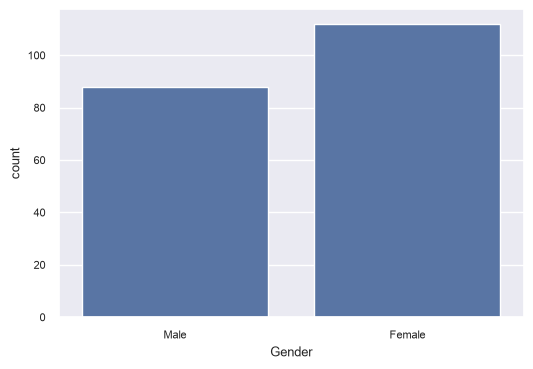

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',data=df)
plt.show()

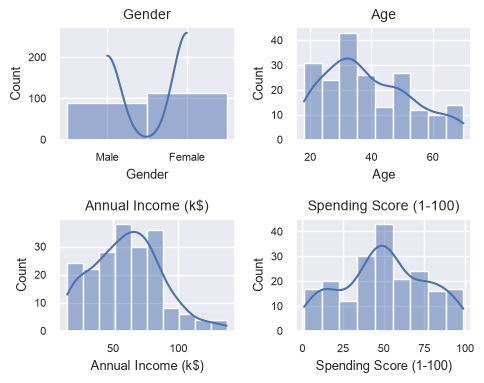

In [56]:
fig,axes=plt.subplots(2,2,figsize=(5,4))
axes=axes.flatten()

for i ,col in enumerate(df.columns):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col)
    
plt.tight_layout()
plt.show()

In [57]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

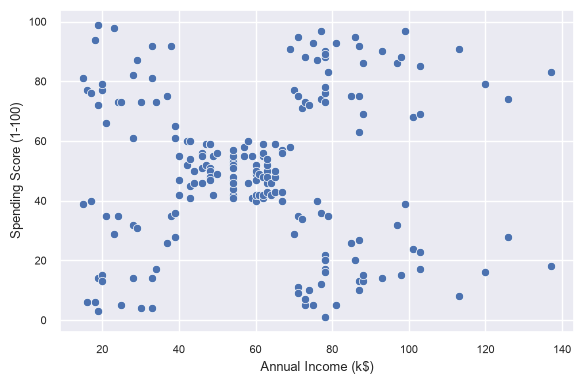

In [58]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Annual Income (k$)'],y=df['Spending Score (1-100)'])
    
plt.tight_layout()
plt.show()


In [59]:
#Feautue selection
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [60]:
columns_to_select=['Annual Income (k$)', 'Spending Score (1-100)']
x=df[columns_to_select]

In [61]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [62]:
#sclae the features (k -means is distance based)
scaler=StandardScaler()

X_scaled=scaler.fit_transform(x)

In [63]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

5 .Elbow method- WCSS

Find best K values (k - Number of clusters)

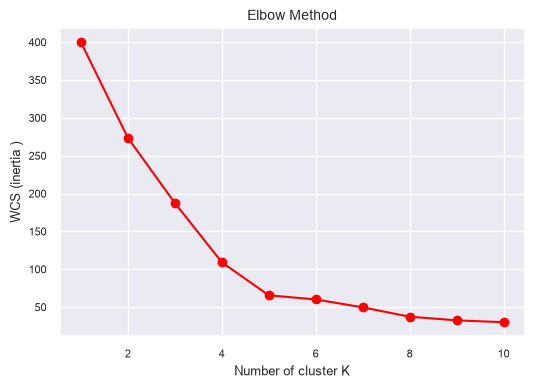

In [64]:
wcss=[]
k_range=range(1,11)
for i in k_range:
    kmeans=KMeans(n_clusters=i,random_state=RANDOM_STATE,max_iter=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    
    
plt.figure(figsize=(6,4))
plt.plot(list(k_range),wcss,marker="o",color='red')
plt.xlabel("Number of cluster K")
plt.ylabel("WCS (inertia )")
plt.title("Elbow Method")
plt.show()

In [65]:
wcss

[400.0,
 273.6688866264201,
 187.55423266634858,
 109.22822707921345,
 65.56840815571682,
 60.13287487193422,
 49.66824483736799,
 37.31912287833883,
 32.49508119910091,
 30.05932269404221]

K means  clusterining

In [66]:
k_final=5
kmeans_final=KMeans(
    n_clusters=k_final,
    random_state=RANDOM_STATE,
    max_iter=10
    
)

In [67]:
kmeans_final.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[[

In [68]:
clusters=kmeans_final.predict(X_scaled)

In [69]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [70]:
#copy of original data frame
df_clusters=df.copy(deep=True)

In [73]:
df_clusters['clusters']=clusters
df_clusters["CustomerID"]=customer_id
df_clusters.head() 

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5


7. Evaluation of Model

In [74]:
k_means_score=silhouette_score(X_scaled,df_clusters["clusters"])
print("K-means clusterring -silhouetee Score:",round(k_means_score,3))

K-means clusterring -silhouetee Score: 0.555


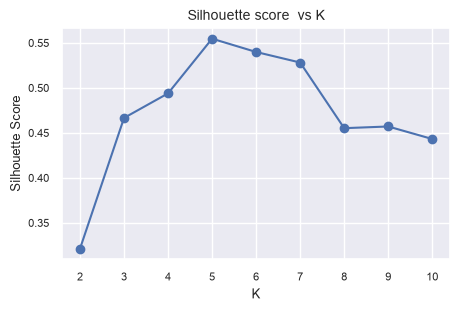

In [ ]:
sil_score=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
    cluster_label=model.fit_predict(X_scaled) 
    sil=silhouette_score(X_scaled,cluster_label)
    sil_score.append(sil)
    
    
plt.figure(figsize=(5,3))
plt.plot(range(2,11),sil_score,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette score  vs K")
plt.show()


7. Visulaize the Clustters

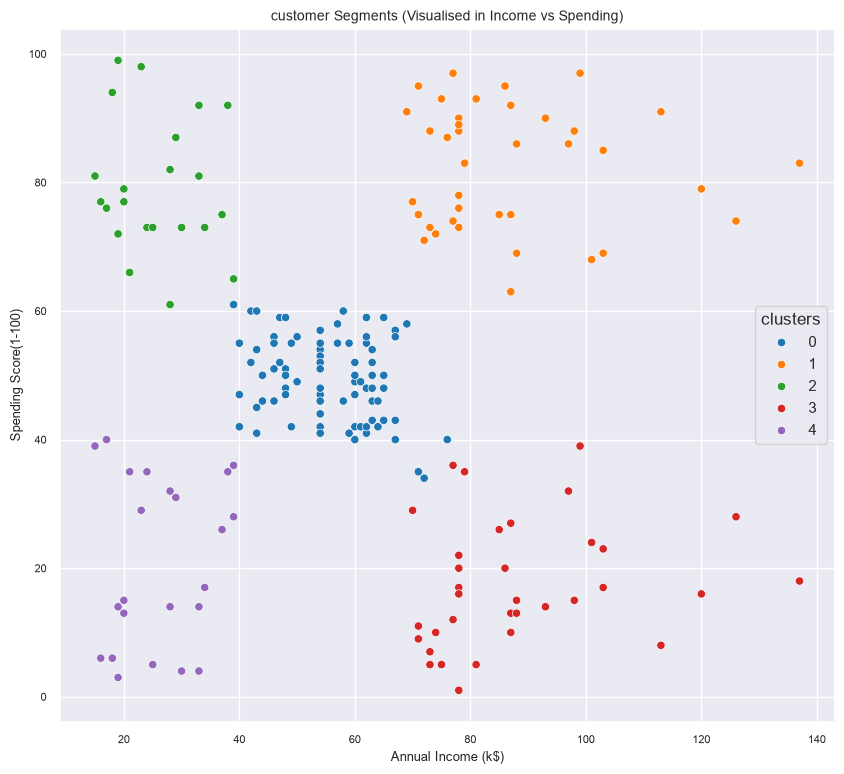

In [81]:
plt.figure(figsize=(10,9))
sns.scatterplot(
    x=df_clusters['Annual Income (k$)'],
    y=df_clusters['Spending Score (1-100)'],
    hue=df_clusters['clusters'],
    palette="tab10"
)

plt.title("customer Segments (Visualised in Income vs Spending)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score(1-100)")
plt.legend(title="clusters")
plt.show()

9. Cluster Ineterpretation (Business Profiling)

In [84]:
profile_cols=["Age",'Annual Income (k$)','Spending Score (1-100)']
cluster_sizes=df_clusters['clusters'].value_counts().sort_index()
cluster_sizes

clusters
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [89]:
cluster_profile_mean=df_clusters.groupby('clusters')[profile_cols].mean().round(2)
cluster_profile_median=df_clusters.groupby('clusters')[profile_cols].median().round(2)
# cluster_profile_mean=df_clusters.groupby('clusters')[profile_cols].mean().round(2)


In [ ]:
cluster_profile_mean

,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,42.720,55.300,49.520
1,32.690,86.540,82.130
2,25.270,25.730,79.360
3,41.110,88.200,17.110
4,45.220,26.300,20.910


In [90]:
cluster_profile_median   

,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,46.000,54.000,50.000
1,32.000,79.000,83.000
2,23.500,24.500,77.000
3,42.000,85.000,16.000
4,46.000,25.000,17.000


In [91]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5
...,...,...,...,...,...,...
195,Female,35,120,79,1,196
196,Female,45,126,28,3,197
197,Male,32,126,74,1,198
198,Male,32,137,18,3,199


In [97]:
def assign_customer_segment(income_k,spending_score,scaler,model):
    new_point=pd.DataFrame([
        [income_k,spending_score]
    ],columns=["Annual Income (k$)",'Spending Score (1-100)'])
    new_point_scaled=scaler.transform(new_point)
    cluster_id=model.predict(new_point_scaled)[0]
    return cluster_id

In [104]:
new_cluster=assign_customer_segment(
    income_k=137,
    spending_score=83,
    scaler=scaler,
    model=kmeans_final
)
print("\n New customer assigned to cluster :", new_cluster)


 New customer assigned to cluster : 1
